In [1]:
import datetime
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

from matplotlib.colors import ListedColormap, BoundaryNorm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GridSearchCV

In [2]:
df = pd.read_pickle(f"../datasets/Clustering.pkl")
df.head()

,experimenter,date,exp_num,raw_id,field,region,cond1,cond2,roi_id,preprocess_id_x_gChirp,...,os_index_movingbar,os_pvalue_movingbar,pref_or_movingbar,on_off_movingbar,d_qi_movingbar,dir_component_movingbar,time_component_movingbar,time_component_dt_movingbar,surrogate_v_movingbar,surrogate_dsi_movingbar
0,Salomon,2025-09-08,2,1,XY1,RR,v,C1,1,1,...,0.276144,0.29,1.251740,-0.30,0.424169,"[0.2692992, 0.21163529, 1.0, 0.0, 0.5561289, 0...","[0.26338604, -0.32434568, 0.50420314, 0.173609...",0.128,"[0.40229368, 0.0, 1.0, 0.22974569, 0.2547209, ...",0.099733
1,Salomon,2025-09-08,2,1,XY1,RR,v,C1,2,1,...,0.154824,0.58,2.867670,-0.06,0.573542,"[0.57404375, 0.5936899, 0.0, 0.09891763, 0.595...","[0.23134468, 0.12591584, -0.19623627, 0.122565...",0.128,"[0.71617424, 0.42367765, 0.0, 0.07766017, 0.33...",0.477601
2,Salomon,2025-09-08,2,1,XY1,RR,v,C1,3,1,...,0.483200,0.02,0.861053,-0.24,0.425207,"[0.35994393, 0.4662192, 0.58913016, 0.14168158...","[0.47586474, -0.5384664, -0.35983962, -0.44003...",0.128,"[0.3359132, 0.3226042, 0.47080025, 0.0, 0.3162...",0.222633
3,Salomon,2025-09-08,2,1,XY1,RR,v,C1,4,1,...,0.158540,0.43,0.351112,0.12,0.508752,"[0.05255287, 1.0, 0.0, 0.9599831, 0.82622796, ...","[-0.6013447, 0.066103116, 0.07772926, 0.050788...",0.128,"[0.35936928, 0.6933557, 0.0, 1.0, 0.77427435, ...",0.087994
4,Salomon,2025-09-08,2,1,XY1,RR,v,C1,5,1,...,0.059757,0.77,2.606700,-0.04,0.386349,"[0.09850365, 0.63157904, 0.0, 0.045831554, 0.4...","[0.06198706, 0.373452, 0.6631308, -0.64670223,...",0.128,"[0.2739429, 0.9214205, 0.08431966, 0.12541033,...",0.238921


In [3]:
df_c1 = df[df["cond2"] == "C1"]
df_c1.head()

,experimenter,date,exp_num,raw_id,field,region,cond1,cond2,roi_id,preprocess_id_x_gChirp,...,os_index_movingbar,os_pvalue_movingbar,pref_or_movingbar,on_off_movingbar,d_qi_movingbar,dir_component_movingbar,time_component_movingbar,time_component_dt_movingbar,surrogate_v_movingbar,surrogate_dsi_movingbar
0,Salomon,2025-09-08,2,1,XY1,RR,v,C1,1,1,...,0.276144,0.29,1.251740,-0.30,0.424169,"[0.2692992, 0.21163529, 1.0, 0.0, 0.5561289, 0...","[0.26338604, -0.32434568, 0.50420314, 0.173609...",0.128,"[0.40229368, 0.0, 1.0, 0.22974569, 0.2547209, ...",0.099733
1,Salomon,2025-09-08,2,1,XY1,RR,v,C1,2,1,...,0.154824,0.58,2.867670,-0.06,0.573542,"[0.57404375, 0.5936899, 0.0, 0.09891763, 0.595...","[0.23134468, 0.12591584, -0.19623627, 0.122565...",0.128,"[0.71617424, 0.42367765, 0.0, 0.07766017, 0.33...",0.477601
2,Salomon,2025-09-08,2,1,XY1,RR,v,C1,3,1,...,0.483200,0.02,0.861053,-0.24,0.425207,"[0.35994393, 0.4662192, 0.58913016, 0.14168158...","[0.47586474, -0.5384664, -0.35983962, -0.44003...",0.128,"[0.3359132, 0.3226042, 0.47080025, 0.0, 0.3162...",0.222633
3,Salomon,2025-09-08,2,1,XY1,RR,v,C1,4,1,...,0.158540,0.43,0.351112,0.12,0.508752,"[0.05255287, 1.0, 0.0, 0.9599831, 0.82622796, ...","[-0.6013447, 0.066103116, 0.07772926, 0.050788...",0.128,"[0.35936928, 0.6933557, 0.0, 1.0, 0.77427435, ...",0.087994
4,Salomon,2025-09-08,2,1,XY1,RR,v,C1,5,1,...,0.059757,0.77,2.606700,-0.04,0.386349,"[0.09850365, 0.63157904, 0.0, 0.045831554, 0.4...","[0.06198706, 0.373452, 0.6631308, -0.64670223,...",0.128,"[0.2739429, 0.9214205, 0.08431966, 0.12541033,...",0.238921


In [4]:
dates = df_c1["date"].unique()

for date in dates:

    df_date = df_c1[df_c1["date"] == date]
    fields = df_date["field"].unique()

    for field in fields:

        df_field = df_date[df_date["field"] == field]
        cond2 = df_field["cond2"].unique()

        df_field_filtered = df_field[df_field["qidx_gChirp"] > 0.35]

        print(f"{date}; {field}: Filtered: {len(df_field_filtered)}, All: {len(df_field)}, In %: {np.round(len(df_field_filtered)/len(df_field)*100, 0)}")

2025-09-08; XY1: Filtered: 6, All: 93, In %: 6.0
2025-09-08; XY2: Filtered: 61, All: 187, In %: 33.0
2025-09-08; XY3: Filtered: 84, All: 134, In %: 63.0
2025-09-08; XY4: Filtered: 8, All: 160, In %: 5.0
2025-09-08; XY6: Filtered: 28, All: 149, In %: 19.0
2025-09-08; XY7: Filtered: 246, All: 249, In %: 99.0
2025-09-08; XY8: Filtered: 221, All: 258, In %: 86.0
2025-10-23; XY7: Filtered: 147, All: 177, In %: 83.0
2025-10-23; XY8: Filtered: 13, All: 183, In %: 7.0
2025-10-23; XY1: Filtered: 1, All: 167, In %: 1.0
2025-10-23; XY2: Filtered: 71, All: 163, In %: 44.0
2025-10-23; XY3: Filtered: 25, All: 113, In %: 22.0
2025-10-23; XY4: Filtered: 189, All: 189, In %: 100.0
2025-10-23; XY5: Filtered: 177, All: 182, In %: 97.0
2025-10-23; XY6: Filtered: 154, All: 166, In %: 93.0
2025-11-19; XY4: Filtered: 187, All: 187, In %: 100.0
2025-11-19; XY5: Filtered: 0, All: 187, In %: 0.0


In [5]:
# Quality threshold for individual recordings
qidx_threshold = 0.35

# Minimum fraction of recordings that need to pass
quality_threshold = 0.30

# Calculate quality for each date-field pair
field_quality = (
    df_c1
    .assign(passes_quality=df_c1["qidx_gChirp"] > qidx_threshold)
    .groupby(["date", "field"])["passes_quality"]
    .mean()
)

# Keep only date-field pairs with >= 30% good recordings
good_fields = field_quality[field_quality >= quality_threshold].index

# Filter the original dataframe
df_c1_filtered = (
    df_c1.set_index(["date", "field"])
         .loc[good_fields]
         .reset_index()
)

print(f"Original rows: {len(df_c1)}")
print(f"Filtered rows: {len(df_c1_filtered)}")

Original rows: 2944
Filtered rows: 1892


In [6]:
df_c1_thresh = df_c1_filtered[df_c1_filtered["qidx_gChirp"] > 0.35]
df_c1_thresh.head()

,date,field,experimenter,exp_num,raw_id,region,cond1,cond2,roi_id,preprocess_id_x_gChirp,...,os_index_movingbar,os_pvalue_movingbar,pref_or_movingbar,on_off_movingbar,d_qi_movingbar,dir_component_movingbar,time_component_movingbar,time_component_dt_movingbar,surrogate_v_movingbar,surrogate_dsi_movingbar
1,2025-09-08,XY2,Salomon,2,1,RR,v,C1,2,1,...,0.186295,0.49,1.909200,-0.28,0.586608,"[0.0, 0.65719897, 0.4722297, 0.22637254, 0.516...","[0.1570872, -0.0126081435, -0.02981854, 0.0112...",0.128,"[0.08978728, 0.63573146, 0.32460654, 0.2757719...",0.190285
2,2025-09-08,XY2,Salomon,2,1,RR,v,C1,3,1,...,0.094192,0.73,1.931740,-0.88,0.644979,"[0.63631666, 0.29250002, 0.8251301, 0.0, 0.573...","[0.09051561, -0.03209947, -0.105276704, 0.1658...",0.128,"[0.77324414, 0.4419419, 0.523655, 0.0, 0.34400...",0.413719
6,2025-09-08,XY2,Salomon,2,1,RR,v,C1,7,1,...,0.243855,0.39,2.283490,-0.40,0.525861,"[0.40543044, 0.5646054, 0.5748889, 0.53034735,...","[0.05895538, 0.19358966, 0.11663305, 0.0421199...",0.128,"[0.20336124, 0.5053507, 0.7100366, 0.36177936,...",0.082813
7,2025-09-08,XY2,Salomon,2,1,RR,v,C1,8,1,...,0.146971,0.60,2.519600,-0.37,0.491576,"[1.0, 0.8134142, 0.5881244, 0.5198129, 0.51120...","[0.014825516, 0.22014785, -0.05181406, -0.0222...",0.128,"[1.0, 0.81511855, 0.62668574, 0.38719317, 0.54...",0.299625
10,2025-09-08,XY2,Salomon,2,1,RR,v,C1,11,1,...,0.442123,0.93,0.933546,-0.36,0.520769,"[0.23970918, 0.79652536, 0.88636494, 0.2290324...","[-0.10132927, -0.20179807, -0.0745436, 0.08598...",0.128,"[0.74423754, 0.6749132, 0.5483166, 0.8723282, ...",0.214294


# Clustering

## gChirp Traces

### PCA

In [18]:
gChirp_averages = df_c1_thresh["average_norm_gChirp"]
#print(f"Shape of all traces: {gChirp_averages.shape}")
#print(f"Shape of single traces: {gChirp_averages[0].shape}")
gChirp_averages

1       [0.48455278264264817, 0.48618484162281833, 0.4...
2       [0.501599497802753, 0.5024032646214401, 0.5032...
6       [-0.009510045468180328, -0.018389086473497473,...
7       [0.48445752677418413, 0.485560437289011, 0.486...
10      [0.34496319501262956, 0.3376935406331655, 0.33...
                              ...                        
1887    [0.1580458740063505, 0.15786600484542243, 0.15...
1888    [0.6414104978263712, 0.6423870129222158, 0.643...
1889    [0.7096592651289781, 0.7127685918246346, 0.715...
1890    [0.2907580071329706, 0.29276444920017014, 0.29...
1891    [0.6983965498699038, 0.7005962210760306, 0.702...
Name: average_norm_gChirp, Length: 1537, dtype: object

In [19]:
# Determine target length (max across all rows)
max_length = gChirp_averages.apply(lambda arr: np.asarray(arr).shape[0]).max()
print("Padding all arrays to length:", max_length)

def pad_to_length(arr, target_length, pad_value=np.nan):
    arr = np.asarray(arr)
    pad_width = target_length - arr.shape[0]
    if pad_width < 0:
        raise ValueError(f"Array longer than target length: {arr.shape[0]} > {target_length}")
    return np.pad(arr, (0, pad_width), mode="constant", constant_values=pad_value)

# Apply padding (using NaN so padded values don't silently look like real data)
padded_traces = gChirp_averages.apply(lambda arr: pad_to_length(arr, max_length))

average_traces_chirp = np.stack(padded_traces.values)
average_traces_chirp.shape

Padding all arrays to length: 16516


(1537, 16516)

In [20]:
x = StandardScaler().fit_transform(gChirp_averages_stacked)
print(x.shape)
print(np.mean(x), np.std(x))

(1537, 16516)
-4.26710365994166e-17 1.0000000000000007


In [21]:
random_state = 69
n_components = 6

components_pca = PCA(n_components=n_components, random_state=random_state)
pca_gchirp = components_pca.fit_transform(x)

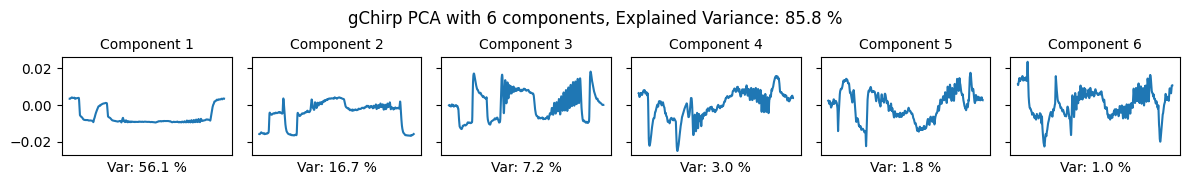

In [22]:
fig, axs = plt.subplots(1, 6, figsize=(12, 2), sharey=True)

fig.suptitle(
    f"gChirp PCA with 6 components, "
    f"Explained Variance: {sum(np.round(components_pca.explained_variance_ratio_ * 100, 1))} %",
    y=0.9
)

for i in range(n_components):
    axs[i].plot(components_pca.components_[i])
    axs[i].set_title(f"Component {i+1}", fontsize=10)
    axs[i].set_xticks([])
    axs[i].set_xlabel(
        f"Var: {np.round(components_pca.explained_variance_ratio_[i] * 100, 1)} %"
    )

plt.tight_layout()
plt.savefig(f"../plots/clustering/PCA_components_gChirp.png")
plt.show()

In [23]:
df_pca_gchirp = pd.DataFrame(
    pca_gchirp,
    columns=[f"PC{i+1}" for i in range(pca_gchirp.shape[1])]
)
df_pca_gchirp.head()

,PC1,PC2,PC3,PC4,PC5,PC6
0,-9.737835,-21.285170,-33.306186,56.451836,54.544355,17.348130
1,25.949071,-32.818090,-32.333061,69.273274,79.308822,28.439713
2,72.060035,71.768363,-49.237883,60.627500,48.920094,14.410864
3,92.002993,44.582332,-31.698427,65.262891,71.434653,18.238999
4,-12.538580,-0.107221,-27.286343,74.482528,55.069054,15.833843


### BIC for number of clusters

In [24]:
# Function to calculate BIC for different number of clusters
def calculate_bic_for_gmm(X, max_clusters):
    bic_values = []
    for n in range(1, max_clusters + 1):
        gmm = GaussianMixture(n_components=n, random_state=random_state).fit(X)
        bic_values.append(gmm.bic(X))
    return bic_values

In [25]:
bic_values = calculate_bic_for_gmm(pca_gchirp, max_clusters=30)
bic_values = np.array(bic_values)

In [26]:
bic_norm = bic_values/bic_values.min()

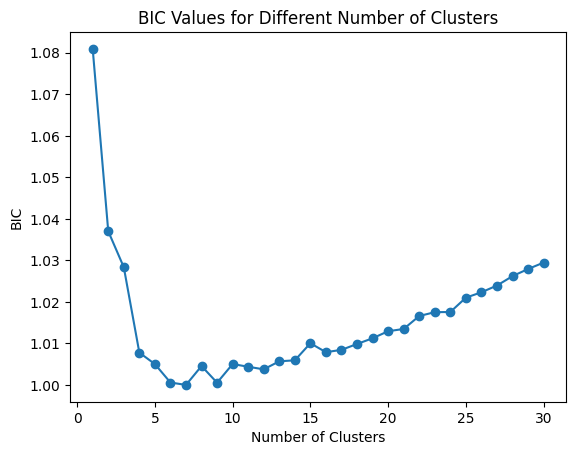

Optimal number of clusters according to BIC: 7


In [27]:
# Plot BIC values
plt.plot(range(1, 31), bic_norm, marker='o')
plt.title('BIC Values for Different Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('BIC')

plt.savefig(f"../plots/clustering/BIC_gchirp.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

# Determine the optimal number of clusters
optimal_clusters = np.argmin(bic_norm) + 1
print(f'Optimal number of clusters according to BIC: {optimal_clusters}')

### GMM

In [28]:
n_components_gmm = 8

gmm = GaussianMixture(n_components=n_components_gmm, random_state=random_state)
gmm.fit(pca_gchirp)

GaussianMixture(n_components=8, random_state=69)

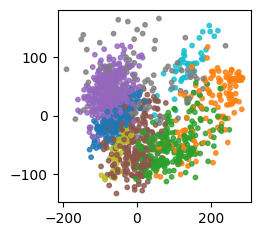

In [29]:
plt.figure(figsize=(2.5,2.5))
plt.scatter(df_pca_gchirp["PC1"], df_pca_gchirp["PC2"],
            c = GaussianMixture(n_components=n_components_gmm).fit_predict(pca_gchirp), cmap="tab10", alpha = 0.8, s=10)

plt.savefig(f"../plots/clustering/PC1_v_PC2_gchirp.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

In [30]:
labels = gmm.predict(pca_gchirp)
df_c1_thresh["cluster_gchirp"] = labels

/tmp/ipykernel_413543/2343826282.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_c1_thresh["cluster_gchirp"] = labels


In [31]:
df_c1_thresh_sorted = df_c1_thresh.sort_values(by=["cluster_gchirp"])
df_c1_thresh_sorted.head()

,date,field,experimenter,exp_num,raw_id,region,cond1,cond2,roi_id,preprocess_id_x_gChirp,...,os_pvalue_movingbar,pref_or_movingbar,on_off_movingbar,d_qi_movingbar,dir_component_movingbar,time_component_movingbar,time_component_dt_movingbar,surrogate_v_movingbar,surrogate_dsi_movingbar,cluster_gchirp
884,2025-10-23,XY2,Salomon,2,1,RR,d,C1,57,1,...,0.08,0.526801,0.06,0.456542,"[1.0, 0.9229995, 0.89175856, 0.0, 0.7674116, 0...","[0.27001625, -0.23437311, -0.07208772, -0.0764...",0.128,"[1.0, 0.8933165, 0.8215667, 0.0, 0.7166773, 0....",0.203319,0
885,2025-10-23,XY2,Salomon,2,1,RR,d,C1,58,1,...,0.53,0.582953,0.01,0.509632,"[0.5933322, 0.6820245, 0.87742937, 0.0, 0.9209...","[-0.48445287, -0.12985203, -0.1669661, 0.14679...",0.128,"[0.5330445, 0.65047204, 0.7899146, 0.0, 1.0, 0...",0.041218,0
886,2025-10-23,XY2,Salomon,2,1,RR,d,C1,59,1,...,0.02,0.444066,0.01,0.495156,"[0.9088704, 0.66546696, 0.3843585, 0.3447403, ...","[-0.38637397, 0.28243056, -0.09554516, 0.30388...",0.128,"[0.8916246, 0.6124501, 0.48304877, 0.42635268,...",0.100086,0
821,2025-09-08,XY8,Salomon,2,1,RR,n,C1,252,1,...,0.00,2.901640,0.69,0.694285,"[1.0, 0.31129512, 0.14485571, 0.4623973, 0.753...","[-0.024042455, -0.022501588, 0.027966293, -0.0...",0.128,"[1.0, 0.3138993, 0.1582667, 0.47068486, 0.7628...",0.157040,0
822,2025-09-08,XY8,Salomon,2,1,RR,n,C1,253,1,...,0.18,2.432380,0.67,0.582164,"[0.26611882, 0.0, 0.37285832, 1.0, 0.8742148, ...","[0.115637176, 0.030290106, -0.01941427, 0.0233...",0.128,"[0.2541483, 0.0, 0.3292917, 1.0, 0.8749478, 0....",0.244994,0


# Play around with the clusters

## Plot number of ROIs per cluster

In [39]:
number_rois_per_cluster = {}

# plot number of rois per cluster
for i in range(n_components_gmm):

    df_cluster = df_c1_thresh_sorted[df_c1_thresh_sorted["cluster_gchirp"] == i]

    n_rois = len(df_cluster)

    number_rois_per_cluster[f"Cluster {i}"] = n_rois

print(number_rois_per_cluster)

{'Cluster 0': 398, 'Cluster 1': 110, 'Cluster 2': 121, 'Cluster 3': 392, 'Cluster 4': 87, 'Cluster 5': 126, 'Cluster 6': 236, 'Cluster 7': 67}


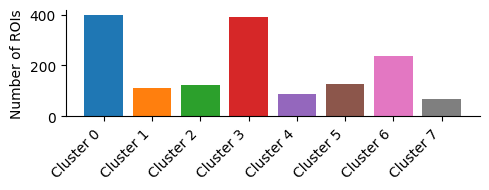

In [40]:
colors = plt.cm.tab10(range(len(number_rois_per_cluster)))

fig, ax = plt.subplots(figsize=(5, 2))

bars = ax.bar(
    number_rois_per_cluster.keys(),
    number_rois_per_cluster.values(),
    color=colors
)

ax.set_ylabel("Number of ROIs")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig(f"../plots/clustering/n_rois_per_cluster.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

## Plot heatmap and avg of traces

### gChirp

In [32]:
gchirp_averages_clusterd = df_c1_thresh_sorted["average_norm_gChirp"]

# Determine target length (max across all rows)
max_length = gchirp_averages_clusterd.apply(lambda arr: np.asarray(arr).shape[0]).max()
print("Padding all arrays to length:", max_length)

# Apply padding (using NaN so padded values don't silently look like real data)
padded_traces = df_c1_thresh_sorted["average_norm_gChirp"].apply(lambda arr: pad_to_length(arr, max_length))

average_traces_chirp = np.stack(padded_traces.values)
average_traces_chirp.shape

Padding all arrays to length: 16516


(1537, 16516)

In [33]:
# --- Add time scale bar ---
fps = 500
seconds_chirp = 5
bar_length_chirp = fps * seconds_chirp  # 2500 frames

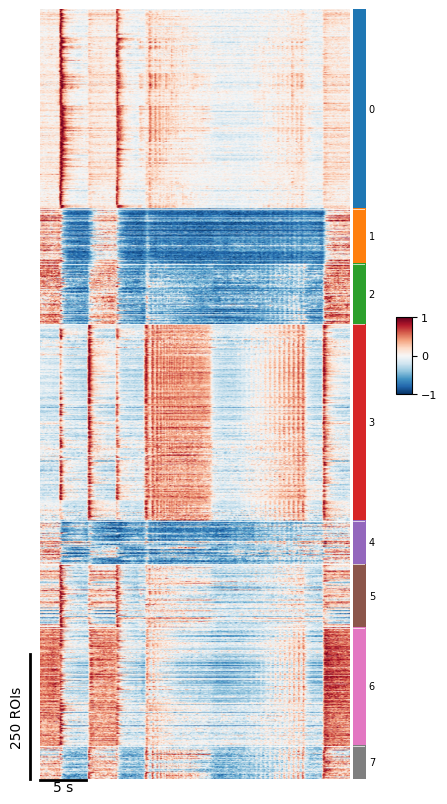

In [49]:
# --- cluster labels, in the same order as the rows of average_traces_chirp ---
df_c1_thresh_sorted = df_c1_thresh.sort_values(by=["cluster_gchirp"], kind="stable")
cluster_labels = df_c1_thresh_sorted["cluster_gchirp"].to_numpy()
assert len(cluster_labels) == average_traces_chirp.shape[0], "Row count mismatch!"

unique_clusters, cluster_codes = np.unique(cluster_labels, return_inverse=True)
n_clusters = len(unique_clusters)
base_cmap = plt.get_cmap("tab10" if n_clusters <= 10 else "tab20")
cluster_cmap = ListedColormap([base_cmap(i % base_cmap.N) for i in range(n_clusters)])
cluster_norm = BoundaryNorm(np.arange(-0.5, n_clusters + 0.5), n_clusters)

fig, ax = plt.subplots(figsize=(4, 10))
im = ax.imshow(average_traces_chirp, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.axis("off")

# --- lock the axes to the image extent BEFORE drawing anything outside it ---
x_lim = ax.get_xlim()          # (-0.5, ncols - 0.5)
y_lim = ax.get_ylim()          # (nrows - 0.5, -0.5)
ax.set_autoscale_on(False)     # prevents the scale bars from expanding the axes

# --- horizontal time scale bar ---
x_start = 0
y_pos = y_lim[0] + 0.5  # just below the plot
ax.plot([x_start, x_start + bar_length_chirp], [y_pos, y_pos], color='black', lw=2, clip_on=False)
ax.text(x_start + bar_length_chirp / 2, y_pos + 0.75,
        f'{seconds_chirp} s', ha='center', va='top', fontsize=10, color="black")

# --- vertical ROI count scale bar (bottom-aligned, just left of the image) ---
n_rois_bar = 250
x_bar = x_lim[0] - 0.03 * (x_lim[1] - x_lim[0])   # small gap relative to image width
y_top_of_bar = y_lim[1] + average_traces_chirp.shape[0] - n_rois_bar
y_bottom_of_bar = y_top_of_bar + n_rois_bar
ax.plot([x_bar, x_bar], [y_top_of_bar, y_bottom_of_bar],
        color='black', lw=2, clip_on=False)
ax.text(x_bar - 0.02 * (x_lim[1] - x_lim[0]), (y_top_of_bar + y_bottom_of_bar) / 2,
        f'{n_rois_bar} ROIs', ha='right', va='center', rotation=90, fontsize=10, color="black")

# --- cluster annotation bar on the right (now exactly the heatmap's height) ---
clax = ax.inset_axes([1.01, 0.0, 0.04, 1.0])
clax.imshow(cluster_codes[:, None], aspect='auto', cmap=cluster_cmap, norm=cluster_norm,
            interpolation='nearest')
clax.axis("off")

boundaries = np.flatnonzero(np.diff(cluster_codes)) + 1
starts = np.concatenate(([0], boundaries))
ends = np.concatenate((boundaries, [len(cluster_codes)]))
for code, s, e in zip(cluster_codes[starts], starts, ends):
    clax.text(1.3, (s + e - 1) / 2, str(unique_clusters[code]),
              transform=clax.get_yaxis_transform(),
              ha='left', va='center', fontsize=7, color="black")
for b in boundaries:
    ax.axhline(b - 0.5, color='white', lw=0.5)
    clax.axhline(b - 0.5, color='white', lw=0.5)

# --- colorbar ---
cax = ax.inset_axes([1.15, 0.5, 0.05, 0.1])
cbar = fig.colorbar(im, cax=cax)
cbar.ax.tick_params(labelsize=8)

plt.savefig("../plots/clustering/heatmap_gchirp_clustered.png",
            bbox_inches="tight", dpi=300)
plt.show()

In [35]:
df_cluster0 = df_c1_thresh_sorted[df_c1_thresh_sorted["cluster_gchirp"] == 0]
averages_cluster0 = df_cluster0["average_norm_gChirp"].values

averages_cluster0.shape

(398,)

In [36]:
mean_response = np.mean(averages_cluster0)
std_response = np.std(averages_cluster0)

print(mean_response.shape, std_response.shape)

(16516,) (16516,)


(-825.75, 17340.75, -0.21714220223484249, 1.0494299678621999)

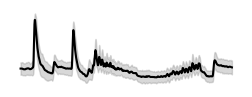

In [37]:
fig,ax = plt.subplots(1,1,figsize=(3,1))

ax.plot(mean_response, color="k")
ax.fill_between(np.arange(0, std_response.shape[0]),
                mean_response + std_response,
                mean_response - std_response,
                alpha=0.3,
                color="gray")
ax.axis("off")

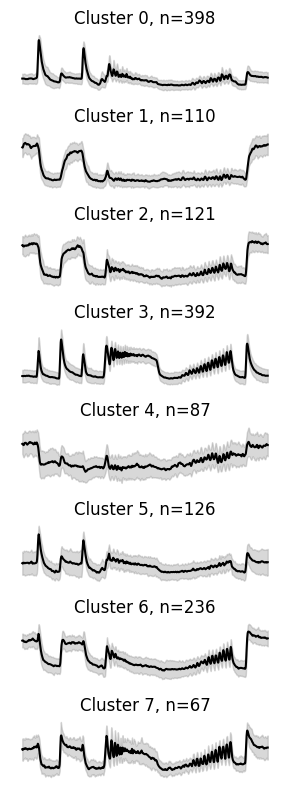

In [38]:
fig, ax = plt.subplots(n_components_gmm, 1, figsize=(3, 1*n_components_gmm))

for i in range(n_components_gmm):

    df_cluster = df_c1_thresh_sorted[df_c1_thresh_sorted["cluster_gchirp"] == i]
    averages_cluster = df_cluster["average_norm_gChirp"].values

    mean = np.mean(averages_cluster)
    std = np.std(averages_cluster)

    ax[i].plot(mean, color="k")
    ax[i].fill_between(np.arange(0, std.shape[0]),
                mean + std,
                mean - std,
                alpha=0.3,
                color="gray")
    ax[i].axis("off")
    ax[i].set_title(f"Cluster {i}, n={len(averages_cluster)}")

plt.tight_layout()
plt.savefig(f"../plots/clustering/averages_gchirp.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

### lChirp

In [39]:
lchirp_averages_clusterd = df_c1_thresh_sorted["average_norm_lChirp"]

# Determine target length (max across all rows)
max_length = lchirp_averages_clusterd.apply(lambda arr: np.asarray(arr).shape[0]).max()
print("Padding all arrays to length:", max_length)

# Apply padding (using NaN so padded values don't silently look like real data)
padded_traces = df_c1_thresh_sorted["average_norm_lChirp"].apply(lambda arr: pad_to_length(arr, max_length))

average_traces_lchirp = np.stack(padded_traces.values)
average_traces_lchirp.shape

Padding all arrays to length: 16516


(1537, 16516)

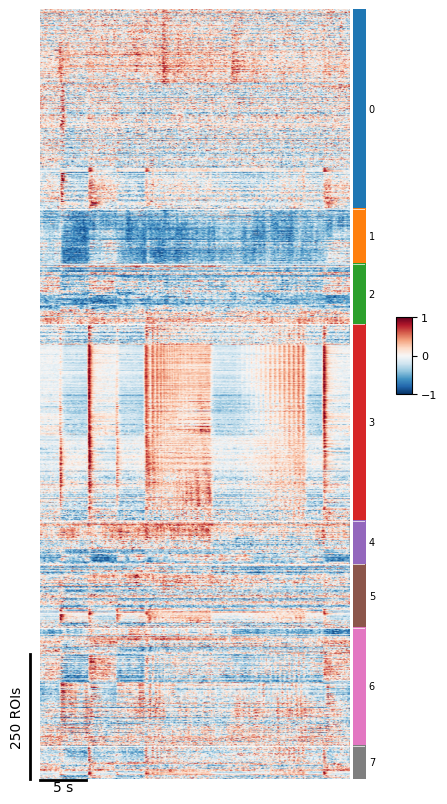

In [48]:
# --- cluster labels, in the same order as the rows of average_traces_lchirp ---
df_c1_thresh_sorted = df_c1_thresh.sort_values(by=["cluster_gchirp"], kind="stable")
cluster_labels = df_c1_thresh_sorted["cluster_gchirp"].to_numpy()
assert len(cluster_labels) == average_traces_lchirp.shape[0], "Row count mismatch!"

unique_clusters, cluster_codes = np.unique(cluster_labels, return_inverse=True)
n_clusters = len(unique_clusters)
base_cmap = plt.get_cmap("tab10" if n_clusters <= 10 else "tab20")
cluster_cmap = ListedColormap([base_cmap(i % base_cmap.N) for i in range(n_clusters)])
cluster_norm = BoundaryNorm(np.arange(-0.5, n_clusters + 0.5), n_clusters)

fig, ax = plt.subplots(figsize=(4, 10))
im = ax.imshow(average_traces_lchirp, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.axis("off")

# --- lock the axes to the image extent BEFORE drawing anything outside it ---
x_lim = ax.get_xlim()          # (-0.5, ncols - 0.5)
y_lim = ax.get_ylim()          # (nrows - 0.5, -0.5)
ax.set_autoscale_on(False)     # prevents the scale bars from expanding the axes

# --- horizontal time scale bar ---
x_start = 0
y_pos = y_lim[0] + 0.5  # just below the plot
ax.plot([x_start, x_start + bar_length_chirp], [y_pos, y_pos], color='black', lw=2, clip_on=False)
ax.text(x_start + bar_length_chirp / 2, y_pos + 0.75,
        f'{seconds_chirp} s', ha='center', va='top', fontsize=10, color="black")

# --- vertical ROI count scale bar (bottom-aligned, just left of the image) ---
n_rois_bar = 250
x_bar = x_lim[0] - 0.03 * (x_lim[1] - x_lim[0])   # small gap relative to image width
y_top_of_bar = y_lim[1] + average_traces_lchirp.shape[0] - n_rois_bar
y_bottom_of_bar = y_top_of_bar + n_rois_bar
ax.plot([x_bar, x_bar], [y_top_of_bar, y_bottom_of_bar],
        color='black', lw=2, clip_on=False)
ax.text(x_bar - 0.02 * (x_lim[1] - x_lim[0]), (y_top_of_bar + y_bottom_of_bar) / 2,
        f'{n_rois_bar} ROIs', ha='right', va='center', rotation=90, fontsize=10, color="black")

# --- cluster annotation bar on the right (now exactly the heatmap's height) ---
clax = ax.inset_axes([1.01, 0.0, 0.04, 1.0])
clax.imshow(cluster_codes[:, None], aspect='auto', cmap=cluster_cmap, norm=cluster_norm,
            interpolation='nearest')
clax.axis("off")

boundaries = np.flatnonzero(np.diff(cluster_codes)) + 1
starts = np.concatenate(([0], boundaries))
ends = np.concatenate((boundaries, [len(cluster_codes)]))
for code, s, e in zip(cluster_codes[starts], starts, ends):
    clax.text(1.3, (s + e - 1) / 2, str(unique_clusters[code]),
              transform=clax.get_yaxis_transform(),
              ha='left', va='center', fontsize=7, color="black")
for b in boundaries:
    ax.axhline(b - 0.5, color='white', lw=0.5)
    clax.axhline(b - 0.5, color='white', lw=0.5)

# --- colorbar ---
cax = ax.inset_axes([1.15, 0.5, 0.05, 0.1])
cbar = fig.colorbar(im, cax=cax)
cbar.ax.tick_params(labelsize=8)

plt.savefig("../plots/clustering/heatmap_lchirp_clustered.png",
            bbox_inches="tight", dpi=300)
plt.show()

Padding all lChirp arrays to length: 16516


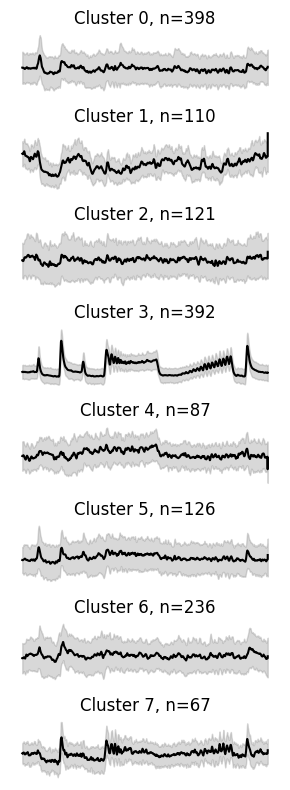

In [42]:
# Determine target length once, across ALL lChirp traces, so every cluster shares the same x-axis
max_length_lchirp = df_c1_thresh_sorted["average_norm_lChirp"].apply(lambda arr: np.asarray(arr).shape[0]).max()
print("Padding all lChirp arrays to length:", max_length_lchirp)

fig, ax = plt.subplots(n_components_gmm, 1, figsize=(3, 1*n_components_gmm))

for i in range(n_components_gmm):

    df_cluster = df_c1_thresh_sorted[df_c1_thresh_sorted["cluster_gchirp"] == i]

    # Pad each trace with NaN, then stack into a 2-D array: (n_rois_in_cluster, max_length_lchirp)
    padded_traces = df_cluster["average_norm_lChirp"].apply(lambda arr: pad_to_length(arr, max_length_lchirp))
    averages_cluster = np.stack(padded_traces.values)

    # nan-aware statistics across ROIs (axis=0), so padded NaNs are ignored
    mean = np.nanmean(averages_cluster, axis=0)
    std = np.nanstd(averages_cluster, axis=0)

    ax[i].plot(mean, color="k")
    ax[i].fill_between(np.arange(0, std.shape[0]),
                mean + std,
                mean - std,
                alpha=0.3,
                color="gray")
    ax[i].axis("off")
    ax[i].set_title(f"Cluster {i}, n={averages_cluster.shape[0]}")

plt.tight_layout()
plt.savefig(f"../plots/clustering/averages_lchirp.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

### Moving bar

In [44]:
mb_averages_clustered = df_c1_thresh_sorted["average_norm_movingbar"]

# Determine target length (max across all rows)
max_length = mb_averages_clustered.apply(lambda arr: np.asarray(arr).shape[0]).max()
print("Padding all arrays to length:", max_length)

# Apply padding (using NaN so padded values don't silently look like real data)
padded_traces = df_c1_thresh_sorted["average_norm_movingbar"].apply(lambda arr: pad_to_length(arr, max_length))

average_traces_mb = np.stack(padded_traces.values)
average_traces_mb.shape

Padding all arrays to length: 2028


(1537, 2028)

In [50]:
# --- Add time scale bar ---
fps = 500
seconds_mb = 1
bar_length_mb = fps * seconds_mb  # 2500 frames

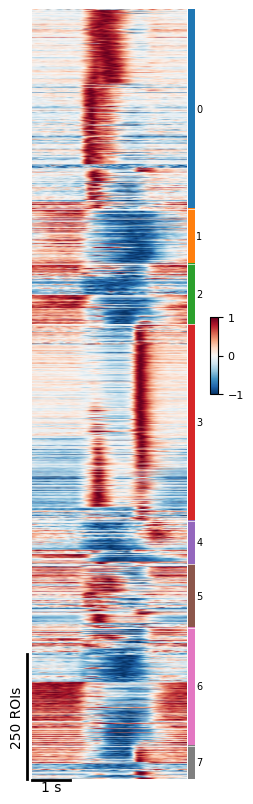

In [53]:
# --- cluster labels, in the same order as the rows of average_traces_lchirp ---
df_c1_thresh_sorted = df_c1_thresh.sort_values(by=["cluster_gchirp"], kind="stable")
cluster_labels = df_c1_thresh_sorted["cluster_gchirp"].to_numpy()
assert len(cluster_labels) == average_traces_mb.shape[0], "Row count mismatch!"

unique_clusters, cluster_codes = np.unique(cluster_labels, return_inverse=True)
n_clusters = len(unique_clusters)
base_cmap = plt.get_cmap("tab10" if n_clusters <= 10 else "tab20")
cluster_cmap = ListedColormap([base_cmap(i % base_cmap.N) for i in range(n_clusters)])
cluster_norm = BoundaryNorm(np.arange(-0.5, n_clusters + 0.5), n_clusters)

fig, ax = plt.subplots(figsize=(2, 10))
im = ax.imshow(average_traces_mb, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.axis("off")

# --- lock the axes to the image extent BEFORE drawing anything outside it ---
x_lim = ax.get_xlim()          # (-0.5, ncols - 0.5)
y_lim = ax.get_ylim()          # (nrows - 0.5, -0.5)
ax.set_autoscale_on(False)     # prevents the scale bars from expanding the axes

# --- horizontal time scale bar ---
x_start = 0
y_pos = y_lim[0] + 0.5  # just below the plot
ax.plot([x_start, x_start + bar_length_mb], [y_pos, y_pos], color='black', lw=2, clip_on=False)
ax.text(x_start + bar_length_mb / 2, y_pos + 0.75,
        f'{seconds_mb} s', ha='center', va='top', fontsize=10, color="black")

# --- vertical ROI count scale bar (bottom-aligned, just left of the image) ---
n_rois_bar = 250
x_bar = x_lim[0] - 0.03 * (x_lim[1] - x_lim[0])   # small gap relative to image width
y_top_of_bar = y_lim[1] + average_traces_mb.shape[0] - n_rois_bar
y_bottom_of_bar = y_top_of_bar + n_rois_bar
ax.plot([x_bar, x_bar], [y_top_of_bar, y_bottom_of_bar],
        color='black', lw=2, clip_on=False)
ax.text(x_bar - 0.02 * (x_lim[1] - x_lim[0]), (y_top_of_bar + y_bottom_of_bar) / 2,
        f'{n_rois_bar} ROIs', ha='right', va='center', rotation=90, fontsize=10, color="black")

# --- cluster annotation bar on the right (now exactly the heatmap's height) ---
clax = ax.inset_axes([1.01, 0.0, 0.04, 1.0])
clax.imshow(cluster_codes[:, None], aspect='auto', cmap=cluster_cmap, norm=cluster_norm,
            interpolation='nearest')
clax.axis("off")

boundaries = np.flatnonzero(np.diff(cluster_codes)) + 1
starts = np.concatenate(([0], boundaries))
ends = np.concatenate((boundaries, [len(cluster_codes)]))
for code, s, e in zip(cluster_codes[starts], starts, ends):
    clax.text(1.3, (s + e - 1) / 2, str(unique_clusters[code]),
              transform=clax.get_yaxis_transform(),
              ha='left', va='center', fontsize=7, color="black")
for b in boundaries:
    ax.axhline(b - 0.5, color='white', lw=0.5)
    clax.axhline(b - 0.5, color='white', lw=0.5)

# --- colorbar ---
cax = ax.inset_axes([1.15, 0.5, 0.05, 0.1])
cbar = fig.colorbar(im, cax=cax)
cbar.ax.tick_params(labelsize=8)

plt.savefig("../plots/clustering/heatmap_mb_clustered.png",
            bbox_inches="tight", dpi=300)

plt.show()

Padding all MB arrays to length: 2028


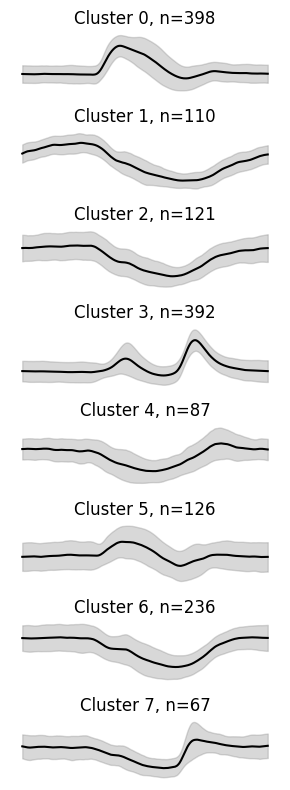

In [55]:
# Determine target length once, across ALL lChirp traces, so every cluster shares the same x-axis
max_length_mb = df_c1_thresh_sorted["average_norm_movingbar"].apply(lambda arr: np.asarray(arr).shape[0]).max()
print("Padding all MB arrays to length:", max_length_mb)

fig, ax = plt.subplots(n_components_gmm, 1, figsize=(3, 1*n_components_gmm))

for i in range(n_components_gmm):

    df_cluster = df_c1_thresh_sorted[df_c1_thresh_sorted["cluster_gchirp"] == i]

    # Pad each trace with NaN, then stack into a 2-D array: (n_rois_in_cluster, max_length_lchirp)
    padded_traces = df_cluster["average_norm_movingbar"].apply(lambda arr: pad_to_length(arr, max_length_mb))
    averages_cluster = np.stack(padded_traces.values)

    # nan-aware statistics across ROIs (axis=0), so padded NaNs are ignored
    mean = np.nanmean(averages_cluster, axis=0)
    std = np.nanstd(averages_cluster, axis=0)

    ax[i].plot(mean, color="k")
    ax[i].fill_between(np.arange(0, std.shape[0]),
                mean + std,
                mean - std,
                alpha=0.3,
                color="gray")
    ax[i].axis("off")
    ax[i].set_title(f"Cluster {i}, n={averages_cluster.shape[0]}")

plt.tight_layout()
plt.savefig(f"../plots/clustering/averages_mb.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

## Correlation over the clusters

### gChirp

In [63]:
gchirp_averages_clusterd = df_c1_thresh_sorted["average_norm_gChirp"]

# Determine target length (max across all rows)
max_length = gchirp_averages_clusterd.apply(lambda arr: np.asarray(arr).shape[0]).max()
print("Padding all arrays to length:", max_length)

# Apply padding (using NaN so padded values don't silently look like real data)
padded_traces = df_c1_thresh_sorted["average_norm_gChirp"].apply(lambda arr: pad_to_length(arr, max_length))

average_traces_gchirp = np.stack(padded_traces.values)
average_traces_gchirp.shape

Padding all arrays to length: 16516


(1537, 16516)

In [64]:
corr_matrix = np.corrcoef(average_traces_gchirp)

print(corr_matrix.shape)

(1537, 1537)


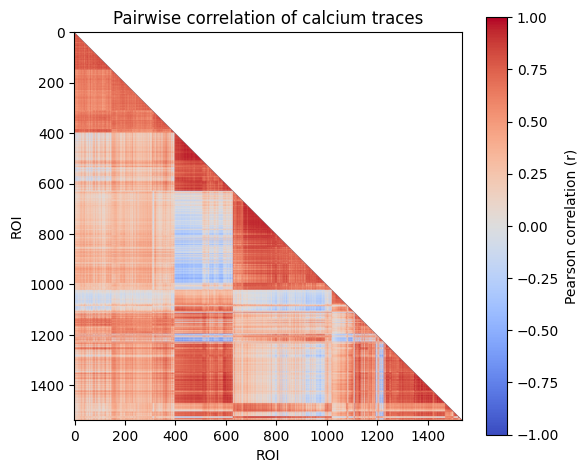

In [65]:
# Mask the upper-right triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(6, 5))

plt.imshow(
    np.ma.masked_where(mask, corr_matrix),
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="equal"
)

plt.colorbar(label="Pearson correlation (r)")
plt.xlabel("ROI")
plt.ylabel("ROI")
plt.title("Pairwise correlation of calcium traces")

plt.tight_layout()
plt.savefig(f"../plots/clustering/correlation_gchirp_sorted_by_cluster.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

### lChirp

In [66]:
lchirp_averages_clusterd = df_c1_thresh_sorted["average_norm_lChirp"]

# Determine target length (max across all rows)
max_length = lchirp_averages_clusterd.apply(lambda arr: np.asarray(arr).shape[0]).max()
print("Padding all arrays to length:", max_length)

# Apply padding (using NaN so padded values don't silently look like real data)
padded_traces = df_c1_thresh_sorted["average_norm_lChirp"].apply(lambda arr: pad_to_length(arr, max_length))

average_traces_lchirp = np.stack(padded_traces.values)
average_traces_lchirp.shape

Padding all arrays to length: 16516


(1537, 16516)

In [71]:
n_rois = average_traces_lchirp.shape[0]

corr_matrix_lchirp = np.full((n_rois, n_rois), np.nan)

for i in range(n_rois):
    for j in range(n_rois):
        valid = ~np.isnan(average_traces_lchirp[i]) & ~np.isnan(average_traces_lchirp[j])

        if valid.sum() >= 2:
            corr_matrix_lchirp[i, j] = np.corrcoef(
                average_traces_lchirp[i, valid],
                average_traces_lchirp[j, valid]
            )[0, 1]

KeyboardInterrupt: 

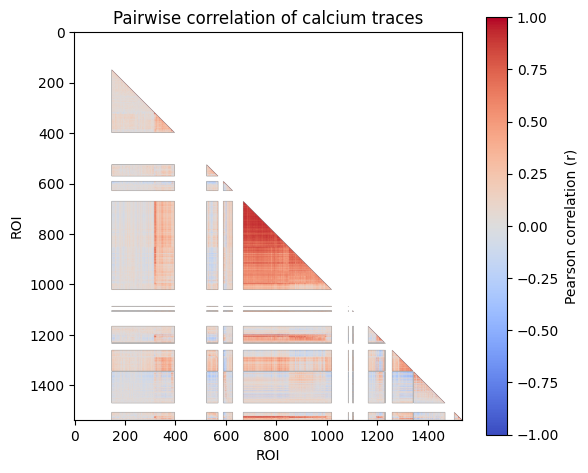

In [70]:
# Mask the upper-right triangle
mask = np.triu(np.ones_like(corr_matrix_lchirp, dtype=bool), k=1)

plt.figure(figsize=(6, 5))

plt.imshow(
    np.ma.masked_where(mask, corr_matrix_lchirp),
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="equal"
)

plt.colorbar(label="Pearson correlation (r)")
plt.xlabel("ROI")
plt.ylabel("ROI")
plt.title("Pairwise correlation of calcium traces")

plt.tight_layout()
plt.savefig(f"../plots/clustering/correlation_lchirp_sorted_by_cluster.png",
            dpi=300,
            bbox_inches="tight")
plt.show()